# Internspark Task - 1

# Customer Behavior Analysis

In [2]:
import pandas as pd
import numpy as np


In [33]:
df = pd.read_csv("ecommerce_customer_data_custom_ratios.csv")

print(df.columns)
df.head()

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')


,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 202404 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            202404 non-null  int64  
 1   Purchase Date          202404 non-null  object 
 2   Product Category       202404 non-null  object 
 3   Product Price          202404 non-null  int64  
 4   Quantity               202404 non-null  int64  
 5   Total Purchase Amount  202404 non-null  int64  
 6   Payment Method         202404 non-null  object 
 7   Customer Age           202404 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          202404 non-null  object 
 10  Age                    202404 non-null  int64  
 11  Gender                 202404 non-null  object 
 12  Churn                  202404 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 21.6+ MB


In [18]:
df.describe().round()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,202404.0,202404.0,202404.0,202404.0,202404.0,202404.0,202404.0,202404.0
mean,25014.0,254.0,3.0,2725.0,44.0,0.0,44.0,0.0
std,14413.0,142.0,1.0,1442.0,15.0,0.0,15.0,0.0
min,1.0,10.0,1.0,101.0,18.0,0.0,18.0,0.0
25%,12547.0,132.0,2.0,1479.0,31.0,0.0,31.0,0.0
50%,25018.0,254.0,3.0,2726.0,44.0,0.0,44.0,0.0
75%,37511.0,377.0,4.0,3970.0,57.0,1.0,57.0,0.0
max,50000.0,500.0,5.0,5350.0,70.0,1.0,70.0,1.0


# Data Cleaning

In [36]:
# Remove missing values
df = df.dropna()

# Remove duplicates
df = df.drop_duplicates()

# Feature Engineering

In [38]:
# convert Date
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [40]:
# create time features
df['Year'] = df['Purchase Date'].dt.year
df['Month'] = df['Purchase Date'].dt.month

In [42]:
# Remove Extra Column
df = df.drop(columns=['Age'])

# Customer Segmentation

In [45]:
# Create RFM Table
import datetime as dt

today = df['Purchase Date'].max()

rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (today - x.max()).days,
    'Customer ID': 'count',
    'Total Purchase Amount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
1,57,1,3491
2,298,2,7029
3,88,7,18172
4,585,1,3154
5,170,6,10239


In [47]:
# Create Segments
rfm['Segment'] = 'Low'

rfm.loc[rfm['Frequency'] > 5, 'Segment'] = 'Medium'
rfm.loc[rfm['Frequency'] > 10, 'Segment'] = 'High'

# Visualization

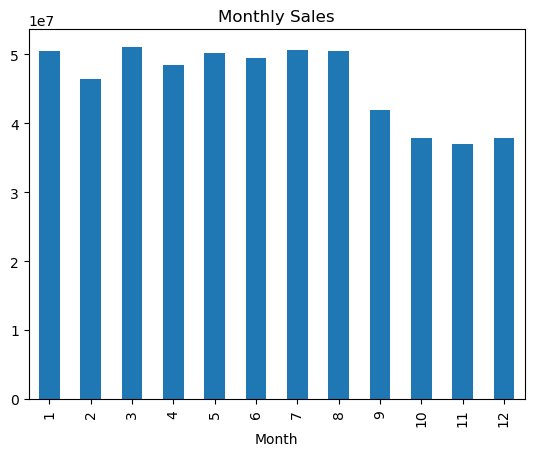

In [50]:
# Monthly Sales
monthly = df.groupby('Month')['Total Purchase Amount'].sum()

monthly.plot(kind='bar')
import matplotlib.pyplot as plt
plt.title("Monthly Sales")
plt.show()

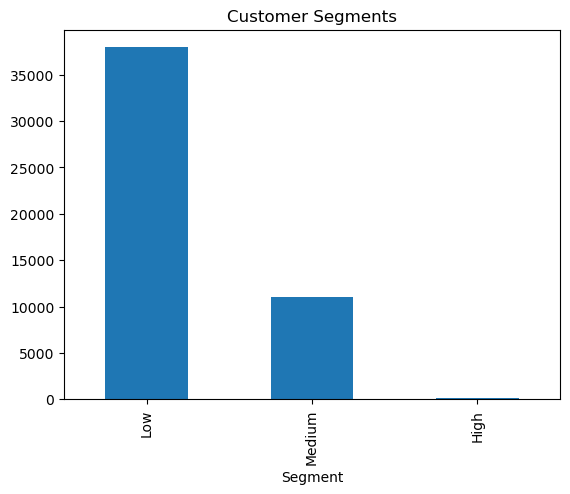

In [52]:
# Customer Segments
rfm['Segment'].value_counts().plot(kind='bar')
plt.title("Customer Segments")
plt.show()

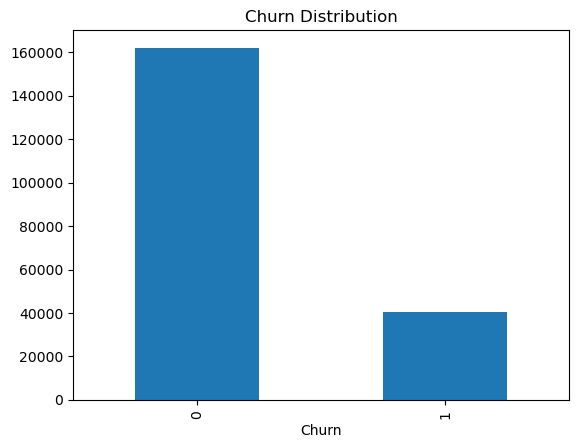

In [54]:
# Churn Analysis
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.show()

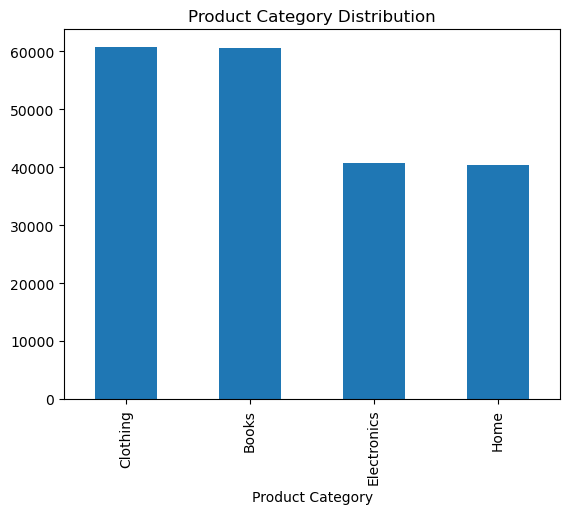

In [59]:
df['Product Category'].value_counts().plot(kind='bar')
plt.title("Product Category Distribution")
plt.show()